# Attribution Truth-Checker

*A walkthrough of the validation system that compares marketing attribution model claims against measured causal incrementality.*

**Author:** Chantel Hill  
**Stack:** Python 3.11, pandas, numpy, matplotlib, Anthropic SDK (Claude Opus 4.7)  
**Repo layout:** `src/` for modules, `scripts/` for CLI runners, `data/synthetic/` for outputs, `notebooks/` for this walkthrough.

---

## The two words this project hinges on

**Attribution** is bookkeeping. The act of assigning credit for a conversion to one or more marketing touchpoints. Last-touch attribution (the simplest version): whichever ad the user clicked last gets all the credit. The output is a number per channel. None of those numbers, by themselves, tell you whether the channel actually *caused* the conversion.

**Incrementality** is causation. The answer to: "If we had not run this channel, how many of these conversions would still have happened?" The conversions that would *not* have happened without the channel are the *incremental* ones. That is the only number a CFO actually cares about, because it is the only number tied to whether a marketing dollar produced a return.

The gap between attribution credit and true incrementality is the entire reason this project exists. A channel can be credited with 30 percent of conversions and be responsible for 5 percent of the actual lift. That is a nine-figure problem at enterprise scale. The truth-checker measures the gap.

## Setup

Imports, paths, and a single call to `apply_style()` from the project's branding module so any inline plots match the rest of the deliverable.

In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'data' / 'synthetic'
PLOTS = DATA / '_verification'
EVAL = DATA / '_evaluation'
GT = DATA / '_ground_truth'

import sys
sys.path.insert(0, str(ROOT))
from src.branding import apply_style  # noqa: E402
apply_style()

pd.set_option('display.max_columns', 12)
pd.set_option('display.width', 140)
print(f'Project root: {ROOT}')
print(f'All data and chart artifacts present: {DATA.exists() and PLOTS.exists() and EVAL.exists()}')

Project root: C:\Users\chant\OneDrive\03_Professional_Documents\attribution_truth_checker
All data and chart artifacts present: True


## Component 1: synthetic data with known ground truth

A validation system needs an answer key. The synthetic data generator builds two parallel realities for the same population:

1. **True causal incrementality.** How many conversions each channel actually caused. Baked in by the generator. This is the secret answer key.
2. **Last-touch attribution credit.** What a deliberately-broken model claims each channel drove. Computed from the same exposure and conversion data.

The synthetic data uses a hazard model: per (user, week), conversion probability is `baseline * demographic_multiplier + sum(channel_rate for active channels)`. We draw a Bernoulli outcome at that probability, and as conversions are drawn we record fractional credit per causal component. The sum across all conversions of each channel's fractional credit is the channel's true incremental conversions.

Six channels are configured with deliberate over-, under-, or accurate-attribution patterns: paid_search (over), display (over), paid_social (accurate), tv_brand (under), direct_mail (under), affiliate (accurate). The reach and true_incremental_rate per channel are tuned in `config/default.yaml` to produce these patterns at the share level.

The four public CSVs the engine sees:

In [2]:
users = pd.read_csv(DATA / 'users.csv')
exposure = pd.read_csv(DATA / 'channel_exposure.csv')
conversions = pd.read_csv(DATA / 'conversions.csv')
model_attr = pd.read_csv(DATA / 'model_attribution.csv')

print(f'users:        {len(users):>9,} rows  ({users.shape[1]} cols)')
print(f'exposure:     {len(exposure):>9,} rows')
print(f'conversions:  {len(conversions):>9,} rows')
print(f'model_attr:   {len(model_attr):>9,} rows')
print()
print('users.head():')
print(users.head().to_string(index=False))

users:          100,000 rows  (5 cols)
exposure:     4,798,973 rows
conversions:     16,448 rows
model_attr:           7 rows

users.head():
 user_id    city age_bucket income_tier  demographic_multiplier
       0 city_00      50-64        high                    1.68
       1 city_00      35-49        high                    2.10
       2 city_00      50-64         mid                    1.20
       3 city_00      35-49         low                    0.90
       4 city_00      18-24         mid                    0.50


### Verifying the generator: did the over- and under-credit pattern emerge?

We compare the answer key (ground truth incremental shares) against the last-touch model's claims. If the generator works, paid_search and display should be over-credited, tv_brand and direct_mail under-credited, paid_social and affiliate roughly accurate.

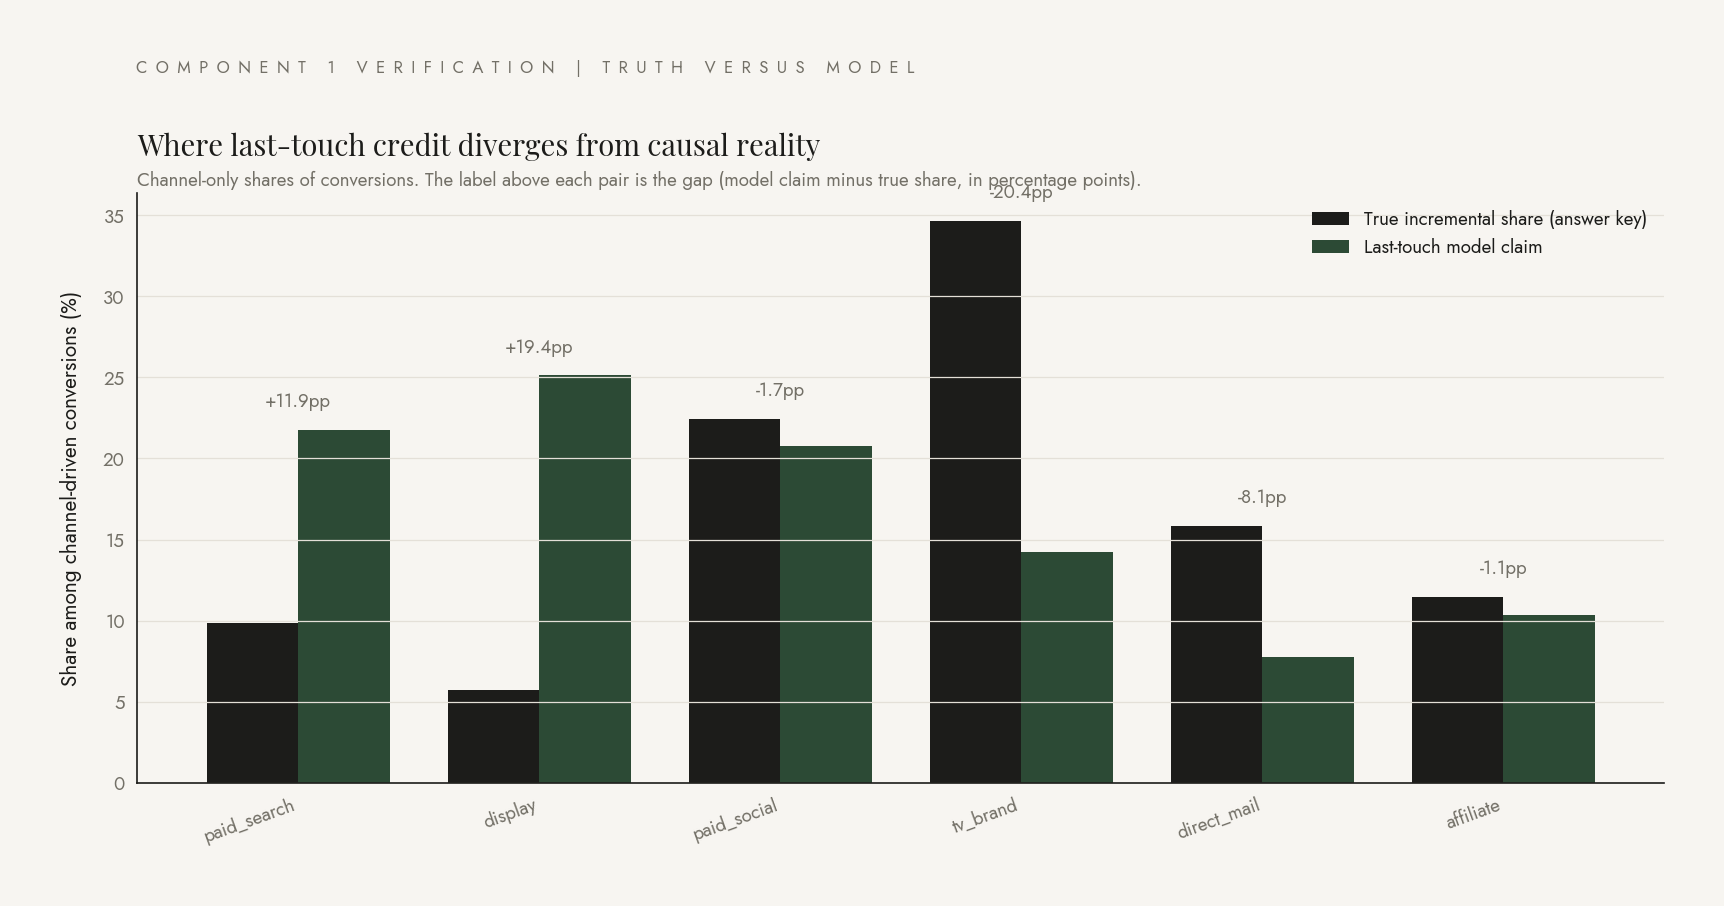

In [3]:
Image(filename=str(PLOTS / 'truth_vs_model.png'))

The pattern is visible: TV brand has the largest blue bar (35% of true causal effect) and one of the smallest red bars (14% of model credit), a -20pp gap. Display has nearly the smallest blue bar (6%) and one of the biggest red bars (25%), a +19pp gap. The synthetic data behaves the way the config says it should.

## Component 2: the geo-lift analysis engine

Now we recover the true causal effects from the public data alone, without consulting the answer key. This is the core measurement work.

**Two-way fixed-effects (TWFE) regression** is the workhorse. The model:

$$\text{conversion\_rate}_{c,w} = \alpha + \beta_1 \cdot \text{search\_active}_{c,w} + \beta_2 \cdot \text{social\_active}_{c,w} + \dots + \text{city\_FE}_c + \text{week\_FE}_w + \epsilon_{c,w}$$

The city fixed effects absorb everything that is constant within a city (baseline conversion rate, demographic mix). The week fixed effects absorb shocks shared across cities (seasonality, news cycles). What is left to identify each $\beta$ is the dark-period variation we baked into the data: when a channel is active in one city-week and dark in another, that contrast is the source of identification.

**Cluster-robust standard errors** (clustered by city) account for the fact that observations within a city are correlated across weeks. Without clustering, p-values would look more confident than they should.

The implementation in `src/methods/did.py` is hand-rolled in numpy: OLS via the normal equations, the cluster-robust sandwich variance formula, Acklam's algorithm for the inverse normal CDF. No statsmodels (no ARM64 wheels), no scipy.stats (blocked by Smart App Control on this machine). Hand-rolling makes the math visible.

In [4]:
measured = pd.read_csv(DATA / 'measured_incrementality.csv')
display_cols = ['channel', 'incremental_rate', 'standard_error', 't_stat', 'p_value', 'measured_incremental_conversions']
print(measured[display_cols].round(5).to_string(index=False))

    channel  incremental_rate  standard_error  t_stat  p_value  measured_incremental_conversions
paid_search           0.00022         0.00021 1.01704  0.30913                         424.06844
    display           0.00033         0.00018 1.80302  0.07139                         631.11160
paid_social           0.00061         0.00017 3.56137  0.00037                        1195.11711
   tv_brand           0.00052         0.00023 2.29964  0.02147                        1035.07593
direct_mail           0.00071         0.00019 3.75845  0.00017                        1403.00260
  affiliate           0.00023         0.00024 0.95860  0.33776                         456.08535


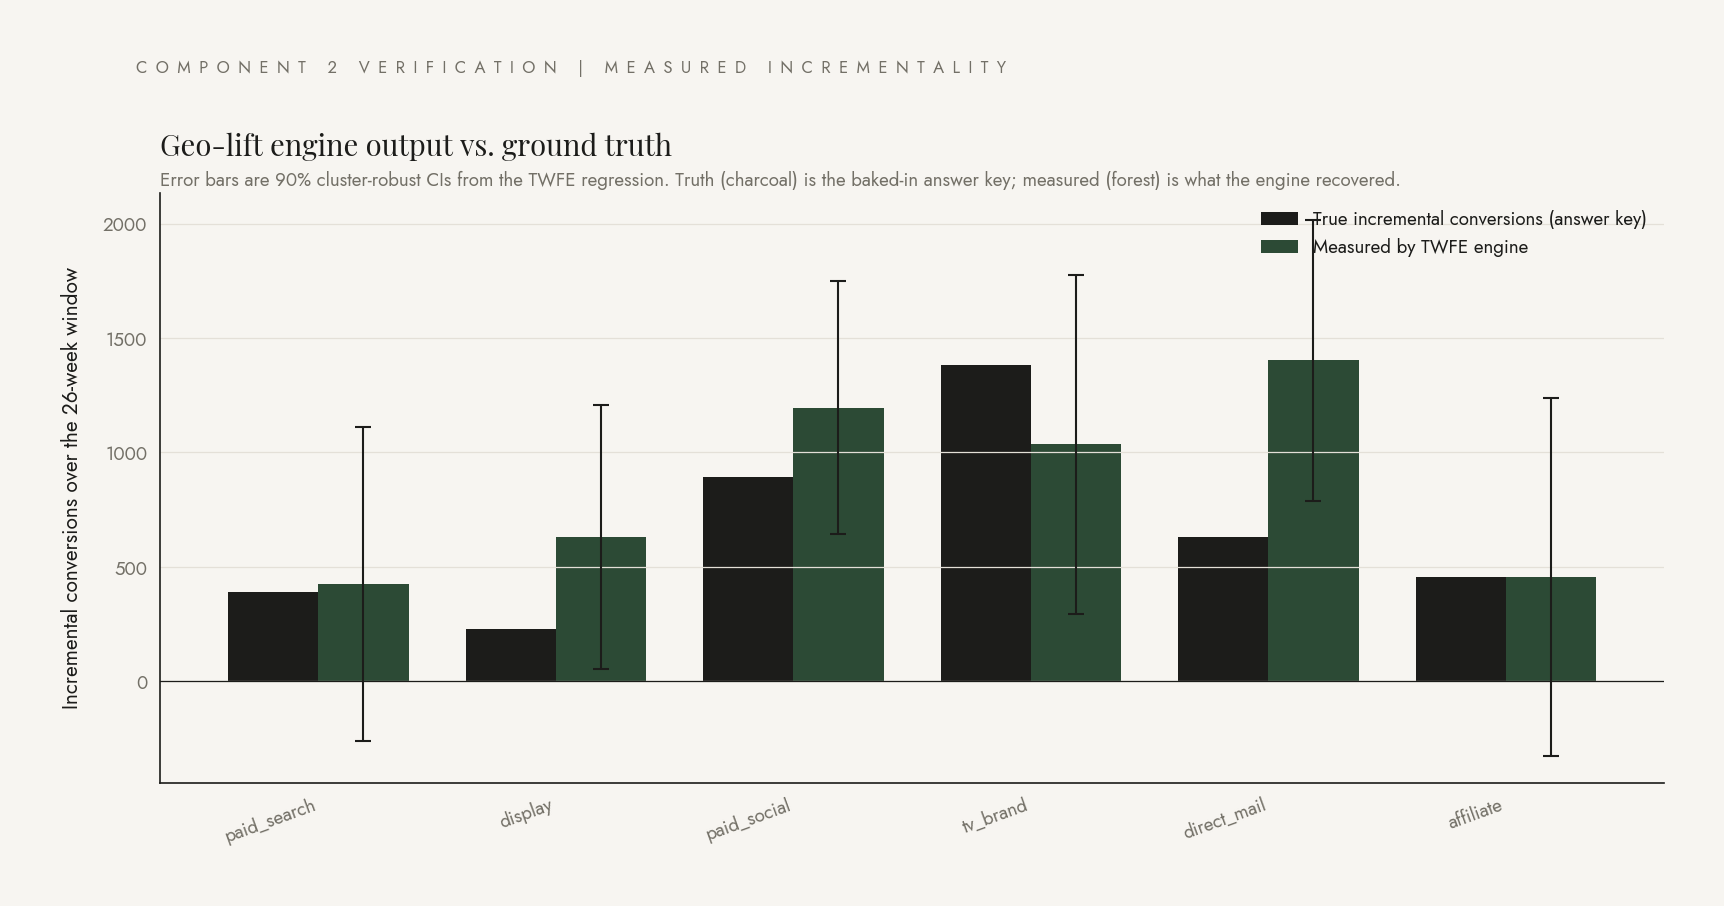

In [5]:
Image(filename=str(PLOTS / 'geolift_measured_vs_true.png'))

All six measured estimates are positive. The two highest-incrementality channels in truth (TV brand and direct mail) are also visibly high in measured. The two lowest (display and paid search) are visibly low. The pattern is right; magnitudes are noisy with finite data, which is the documented limitation of multi-channel TWFE — single-channel synthetic control would tighten per-channel magnitudes but is out of scope for Phase 1.

## Component 3: the truth-check itself

Compare model claim against measured incrementality, channel by channel. The comparison is on **shares**, not absolute conversion counts. Last-touch attribution attributes nearly all conversions to channels because it has no concept of baseline conversions; in absolute terms every channel looks over-credited by 2-5x. The interesting question is which channels are *relatively* over- or under-credited compared to their actual causal contribution.

Three-class labeling rule: if `|model_share - measured_share| > 5pp`, flag as OVER_CREDITED or UNDER_CREDITED depending on direction. Otherwise ACCURATE.

In [6]:
comparison = pd.read_csv(DATA / 'comparison.csv')
summary_cols = ['channel', 'model_share_pct', 'measured_share_pct', 'share_gap_pp', 'label']
print(comparison[summary_cols].round(2).to_string(index=False))

total_model = comparison['model_attributed_conversions'].sum()
total_measured = comparison['measured_incremental_conversions'].sum()
print()
print(f'Aggregate over-attribution: model claims {total_model:,.0f} conversions vs {total_measured:,.0f} measured ({total_model / total_measured:.1f}x).')

    channel  model_share_pct  measured_share_pct  share_gap_pp          label
direct_mail             7.75               27.27        -19.52 UNDER_CREDITED
paid_search            21.76                8.24         13.51  OVER_CREDITED
    display            25.13               12.27         12.86  OVER_CREDITED
   tv_brand            14.26               20.12         -5.86 UNDER_CREDITED
paid_social            20.76               23.23         -2.47       ACCURATE
  affiliate            10.34                8.87          1.47       ACCURATE

Aggregate over-attribution: model claims 16,426 conversions vs 5,144 measured (3.2x).


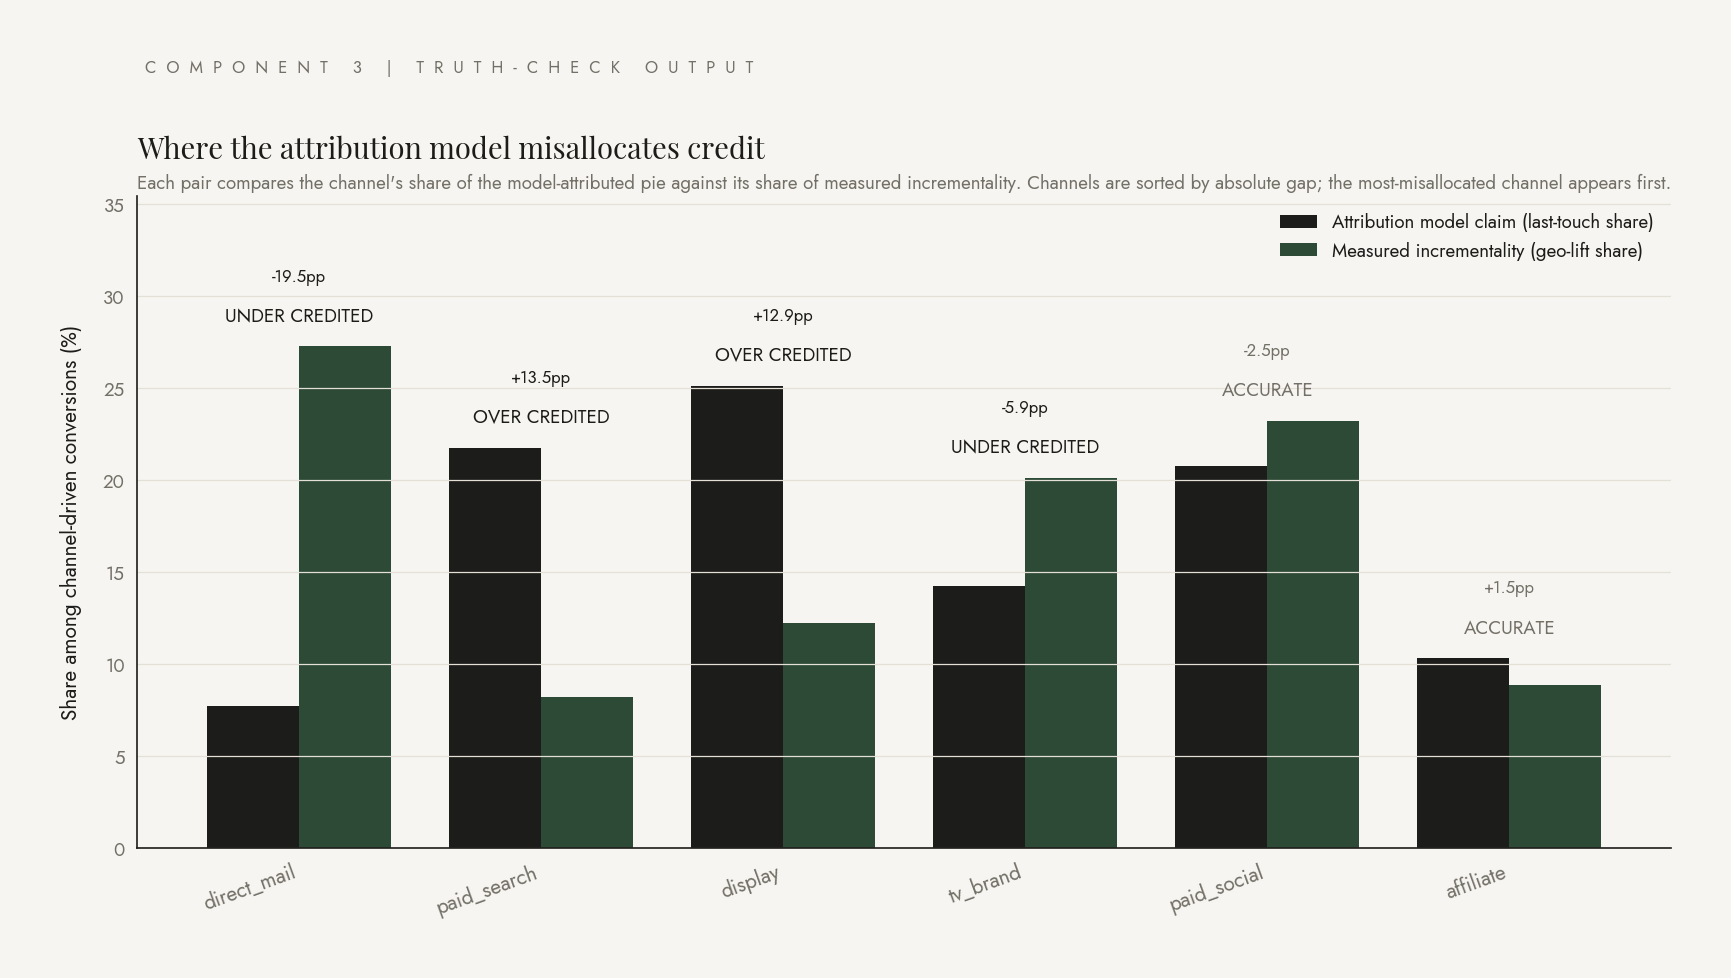

In [7]:
Image(filename=str(PLOTS / 'comparison.png'))

**The headline:** direct_mail is the most under-credited channel (-19.5pp), getting 7.7% of attribution credit when its measured share is 27.3%. Paid search and display are most over-credited (+13.5pp and +12.9pp). Paid social and affiliate are within measurement noise.

## Component 4: Claude API executive narrative

The comparison data is the right answer in numbers. An executive wants paragraphs. We feed the comparison data to `claude-opus-4-7` with a carefully-structured prompt and get back an executive summary.

Three prompt-engineering choices worth pointing out:

1. **Style rules sit in the system prompt** as hard constraints (no em dashes, no "obviously" or "clearly", every numeric claim must trace back to a number in the data). System prompts are stable across calls; the user message is what varies.
2. **Negative constraints work better than positive ones for tone control.** "Avoid 'obviously' and 'clearly'" is more effective than "be humble."
3. **The skip-list approach.** Telling the model which channels to discuss vs omit is more reliable than asking it to filter on its own.

Cost: ~$0.026 per call (about 1300 input + 800 output tokens at Opus 4.7 prices).

In [8]:
from src.narrative import SYSTEM_PROMPT
print(SYSTEM_PROMPT[:600] + '...')  # show the head of the system prompt

You are a senior marketing analytics consultant writing executive summaries that translate technical attribution analysis into plain-language recommendations. Your audience is a CFO, CMO, or CEO reading this on a Monday morning. They want to know what changed, by how much, and what to do.

STYLE RULES (non-negotiable):
- No em dashes anywhere. Use commas, periods, parentheses, or colons instead.
- Confident but not arrogant. Avoid the words "obviously" and "clearly" entirely.
- Every numeric claim must trace back to a specific number in the input data. Do not invent precision or round in ways ...


In [9]:
narrative_text = (DATA / 'narrative.md').read_text(encoding='utf-8')
Markdown(narrative_text)

Our last-touch attribution is overstating channel-driven conversions by roughly 3.2x (16,426 claimed versus 5,144 measured as truly incremental over 26 weeks), and the mix inside that number is wrong in ways that should change next quarter's budget.

**Direct mail is badly under-credited.** The model gives it 7.7% of channel credit, but geo-lift measurement puts its true contribution at 27.3%, a 19.5 percentage point gap and the largest mismatch in the portfolio. The measurement is statistically tight (p-value 0.000), so this is not noise. Direct mail is doing far more work than the dashboards show, and the recommended action is to protect and likely expand its budget rather than trim it in the next planning cycle.

**Paid search is the most over-credited channel in absolute terms.** The model assigns it 21.8% of channel credit; measurement supports only 8.2%, a swing of roughly 3,150 conversions that paid search is getting credit for but not actually causing. One important caveat: the p-value on the paid search measurement is 0.309, meaning the precise size of the overstatement is uncertain. The direction is consistent with brand search cannibalization, so the action is to run a planned paid search holdout test in one or two geos this quarter before making large cuts.

**Display is over-credited and the evidence is stronger.** The model claims 25.1% of channel credit; measurement shows 12.3%, a 12.9 percentage point gap and about 3,497 conversions of overstatement. The p-value of 0.071 is suggestive rather than conclusive, but the gap is large enough that the prudent move is to reduce display spend by a meaningful step (start with 20 to 30%) and reinvest the savings into the under-credited channels while monitoring total conversions.

**TV brand is under-credited with solid statistical support.** The model gives it 14.3% of credit; measurement says 20.1%, a 5.9 percentage point gap with a p-value of 0.021. TV is pulling more weight than the attribution model recognizes, particularly on upper-funnel demand that paid search and display are then taking credit for. Hold or modestly increase TV brand investment, and stop using last-touch numbers to justify cuts to it.

This week, commission the paid search geo holdout and rebalance roughly 15 to 20% of display budget toward direct mail and TV brand pending those results.


## Component 6: precision, recall, F1 — the validation discipline

Marketing teams rarely apply classification metrics to attribution decisions because attribution outputs look continuous (credit shares), not categorical. But the *decisions* the truth-checker outputs (OVER_CREDITED, UNDER_CREDITED, ACCURATE) are explicitly a 3-class classification problem. Treating it that way and grading it with precision, recall, and F1 brings the same evaluation discipline used for clause classifiers in legal AI into a domain that doesn't usually have it.

We run the full pipeline 50 times with different seeds. Configured labels stay constant; predicted labels vary with measurement noise. 50 simulations × 6 channels = 300 predictions, ~100 per class — enough for stable per-class metrics.

In [10]:
summary = json.loads((EVAL / 'metrics_summary.json').read_text())
print(f'Total predictions: {summary["total_predictions"]}')
print(f'Accuracy:          {summary["accuracy"]:.3f}')
print(f'Macro-F1:          {summary["macro_f1"]:.3f}')
print(f'Weighted-F1:       {summary["weighted_f1"]:.3f}')
print()
print(f'{"class":<18} {"support":>8} {"precision":>10} {"recall":>8} {"F1":>6}')
print(f'{"-" * 18} {"-" * 8} {"-" * 10} {"-" * 8} {"-" * 6}')
for pc in summary['per_class']:
    print(f'{pc["label"]:<18} {pc["support"]:>8} {pc["precision"]:>10.3f} {pc["recall"]:>8.3f} {pc["f1"]:>6.3f}')

Total predictions: 300
Accuracy:          0.690
Macro-F1:          0.678
Weighted-F1:       0.678

class               support  precision   recall     F1
------------------ -------- ---------- -------- ------
OVER_CREDITED           100      0.773    0.850  0.810
UNDER_CREDITED          100      0.675    0.790  0.728
ACCURATE                100      0.589    0.430  0.497


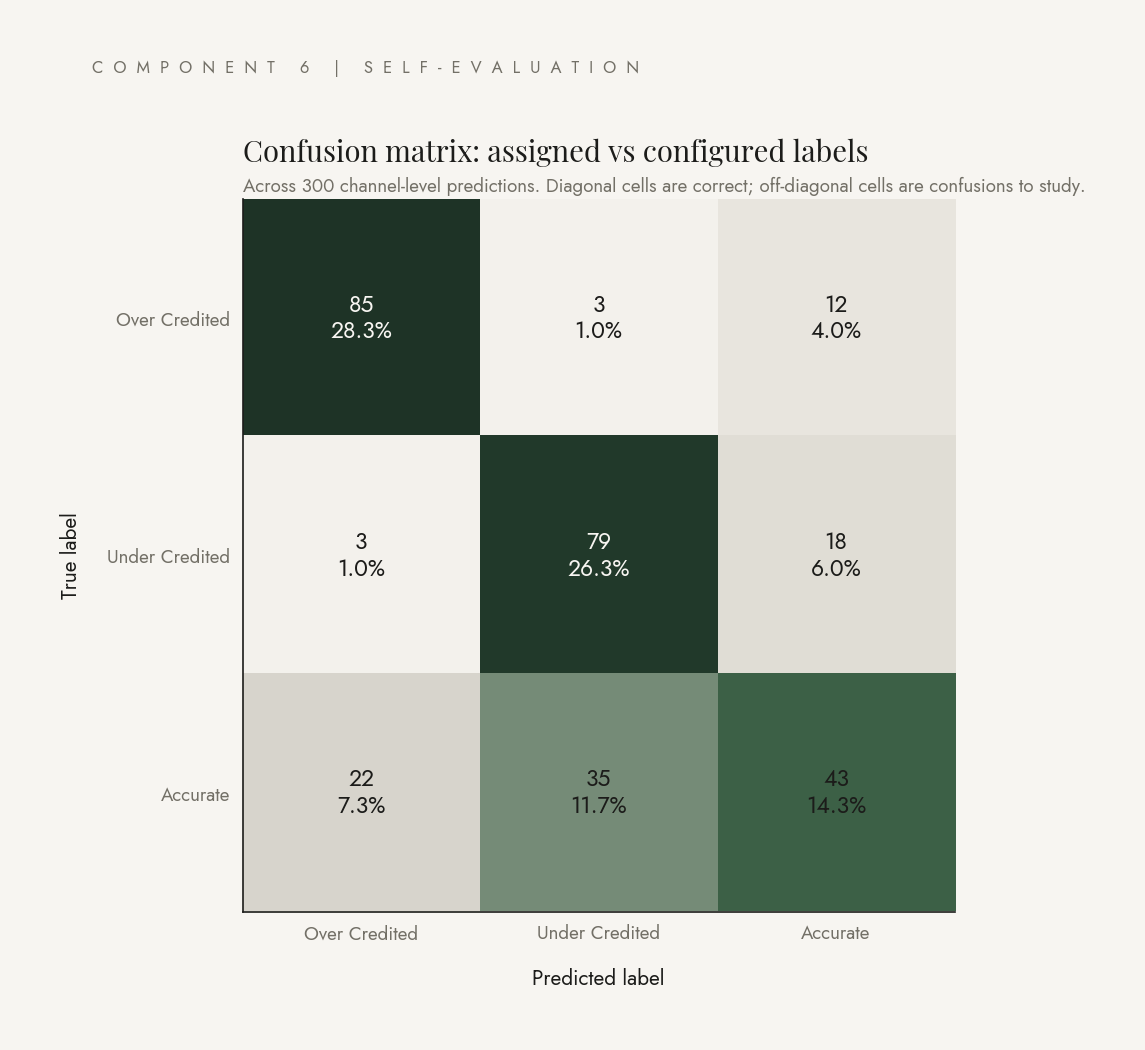

In [11]:
Image(filename=str(PLOTS / 'confusion_matrix.png'))

Three observations from the confusion matrix:

1. **OVER and UNDER almost never get confused with each other.** 3 out of 100 in each direction. The system never tells you to cut a channel that should be expanded, or vice versa. The mistakes are about magnitude, not direction.
2. **Recall on actionable classes is high.** 85% on OVER, 79% on UNDER. When there is real misallocation, the system catches it.
3. **The weakness is on the ACCURATE class.** 43% recall — the system over-flags channels that are actually fine. The threshold sweep below shows how to fix this.

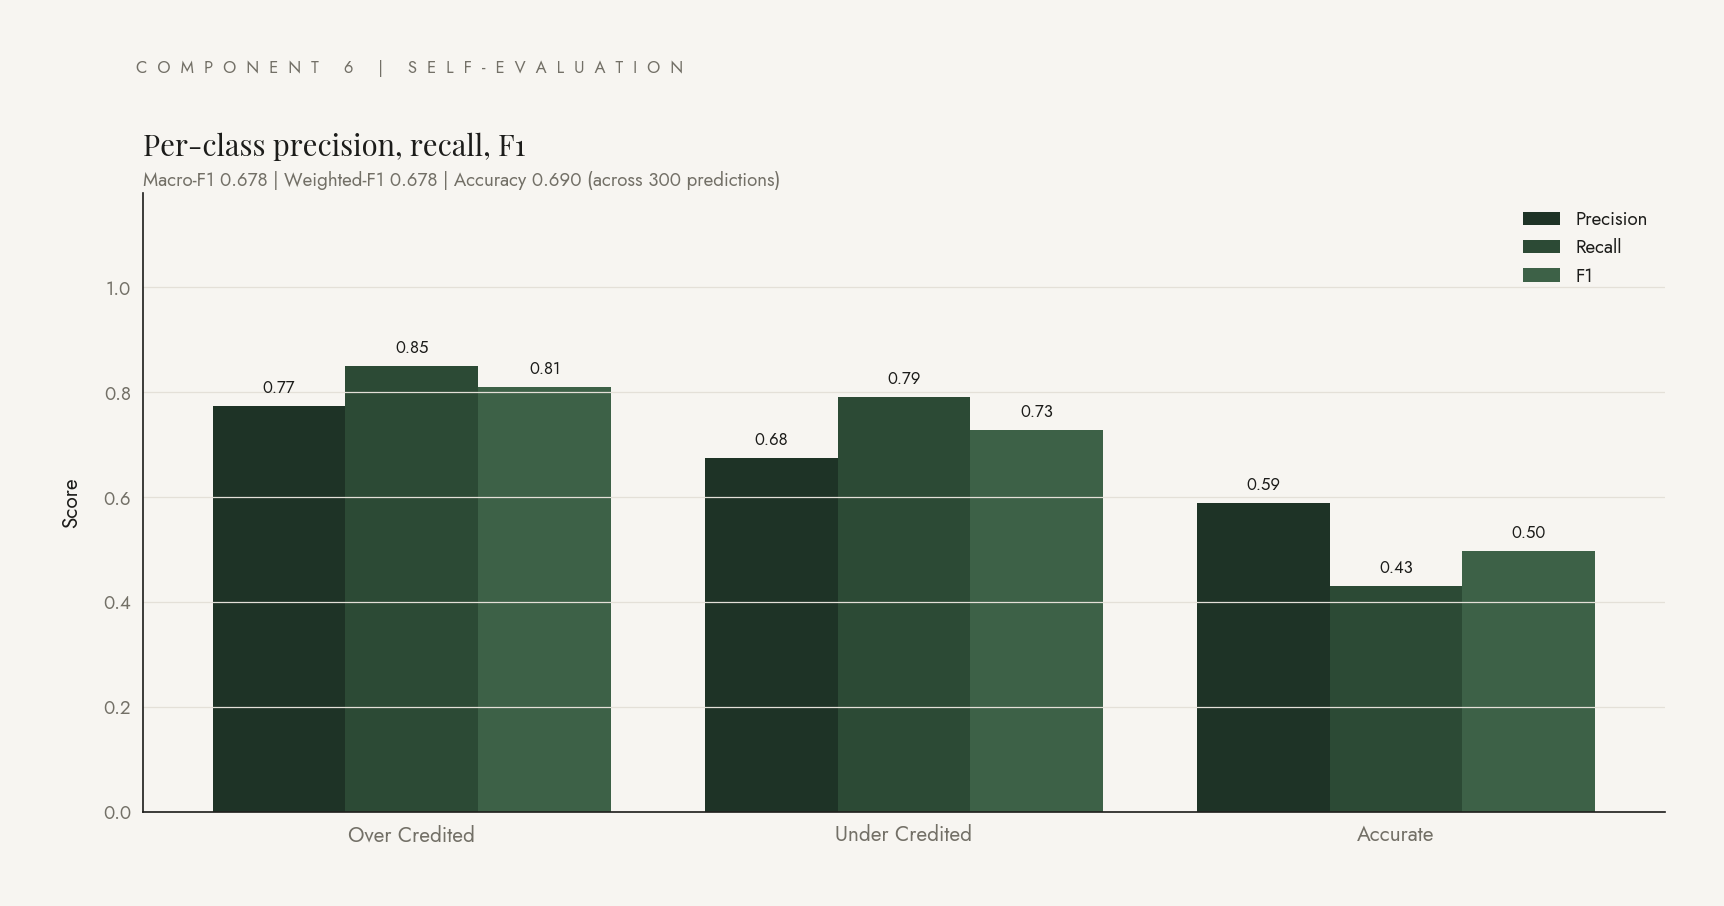

In [12]:
Image(filename=str(PLOTS / 'per_class_metrics.png'))

### Component 6 extension: threshold sweep

The 5pp gap threshold I picked for the comparison layer was an educated guess. Sweeping it across [1pp, 15pp] in 0.5pp steps and recomputing metrics at each candidate point shows where F1 actually peaks per class.

In [13]:
optimal = json.loads((EVAL / 'optimal_thresholds.json').read_text())
print(f'{"class":<18} {"opt threshold":>14} {"F1":>6} {"precision":>10} {"recall":>8}')
print(f'{"-" * 18} {"-" * 14} {"-" * 6} {"-" * 10} {"-" * 8}')
for cls in ['OVER_CREDITED', 'UNDER_CREDITED', 'ACCURATE']:
    o = optimal[cls]
    print(f'{cls:<18} {o["threshold_pp"]:>13.1f}pp {o["f1"]:>6.3f} {o["precision"]:>10.3f} {o["recall"]:>8.3f}')
print()
macro = optimal['_macro']
print(f'Macro-F1 optimum at {macro["threshold_pp"]:.1f}pp: macro-F1 = {macro["macro_f1"]:.3f}')

class               opt threshold     F1  precision   recall
------------------ -------------- ------ ---------- --------
OVER_CREDITED                8.0pp  0.837      0.854    0.820
UNDER_CREDITED               6.5pp  0.740      0.713    0.770
ACCURATE                    13.5pp  0.638      0.497    0.890

Macro-F1 optimum at 8.0pp: macro-F1 = 0.709


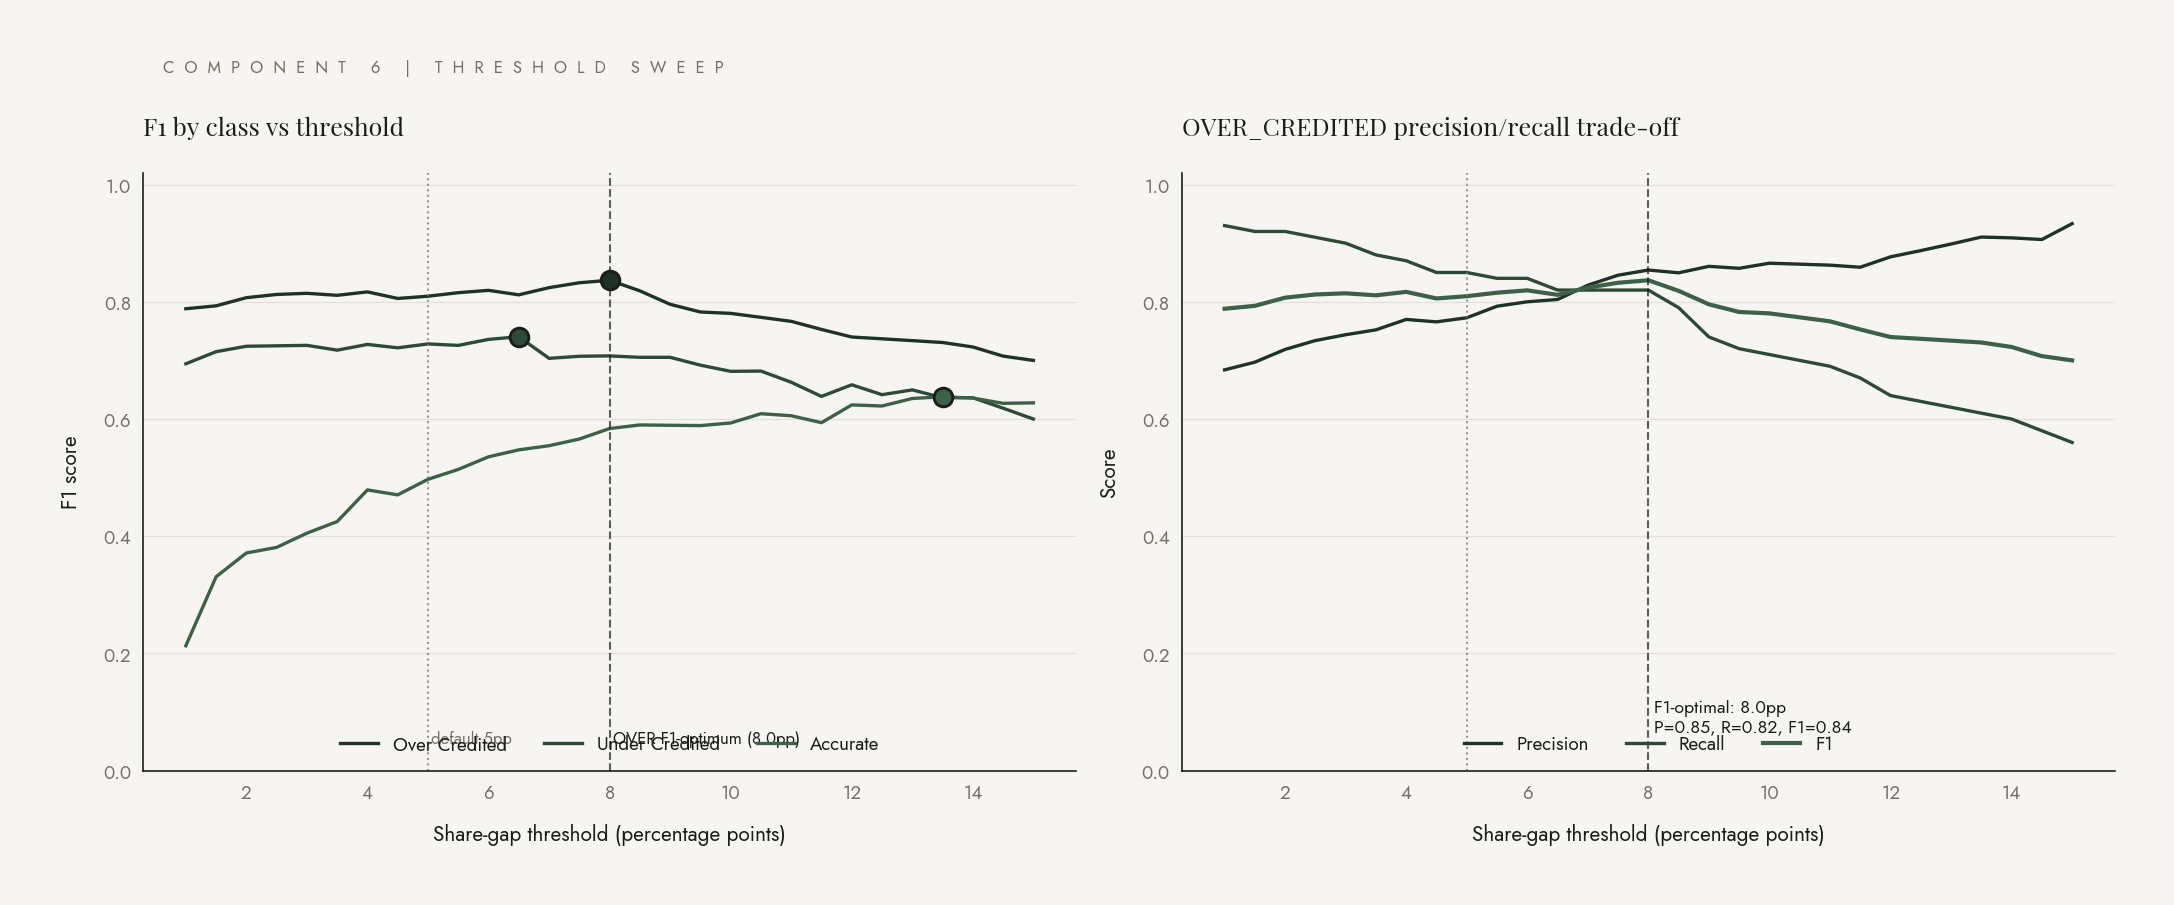

In [14]:
Image(filename=str(PLOTS / 'threshold_sweep.png'))

F1-optimal threshold for OVER_CREDITED — the budget-relevant class — is **8.0pp**, not the default 5pp. Modest +0.027 F1 gain. The bigger gain is for the ACCURATE class at 13.5pp (+0.141 F1), which would substantially cut the false-flag rate.

### Component 6 extension: calibration check

When the system says it is confident in a label, is it actually correct that often? Confidence is defined as the margin from the decision boundary: an OVER prediction with share gap 15pp is high-confidence; one at 5.5pp is barely-above-threshold.

The Expected Calibration Error (ECE) summarizes the gap between stated confidence and empirical accuracy. 0 is perfect; <0.05 is well-calibrated; >0.10 is meaningfully miscalibrated.

In [15]:
cal_summary = json.loads((EVAL / 'calibration_summary.json').read_text())
print(f'Expected Calibration Error: {cal_summary["expected_calibration_error"]:.3f}')
print(f'Verdict: {"WELL CALIBRATED" if cal_summary["expected_calibration_error"] < 0.05 else ("MILD" if cal_summary["expected_calibration_error"] < 0.1 else "MEANINGFULLY MISCALIBRATED")}')

Expected Calibration Error: 0.155
Verdict: MEANINGFULLY MISCALIBRATED


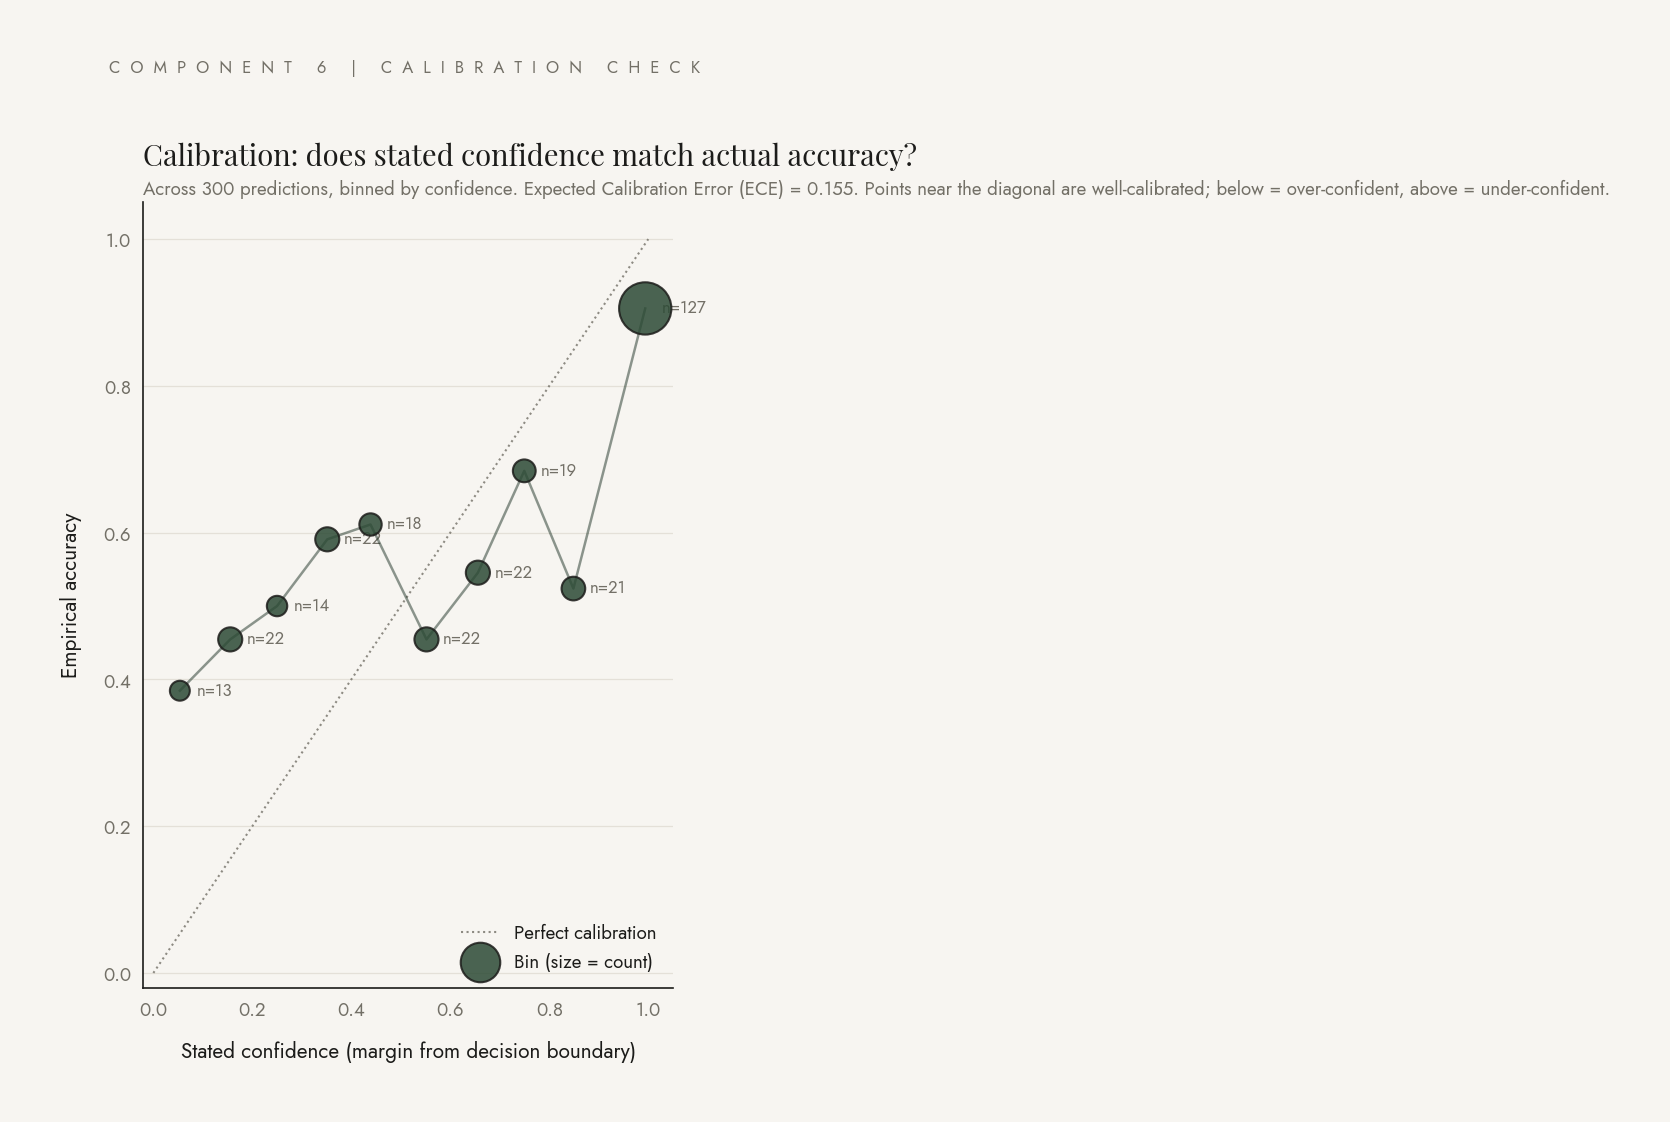

In [16]:
Image(filename=str(PLOTS / 'calibration.png'))

**The system is well-calibrated at the extremes** but over-confident in the moderate-confidence range. At 85% stated confidence, empirical accuracy is only 52%. That is the kind of failure mode you cannot see in macro-F1 alone, and it is what you would want to fix before the truth-checker is used for budget decisions where moderate-confidence findings get acted on.

### Component 6 extension: LLM-grades-LLM narrative evaluation

Take Claude's executive summary, structure the comparison data as ground truth, and have Claude grade Claude on whether the narrative's claims are consistent with the data.

Per channel labeled OVER or UNDER, the grader returns three booleans:

1. `channel_mentioned` — does the narrative discuss this channel by name?
2. `direction_correct` — does the narrative correctly state over- vs under-credited?
3. `magnitude_approximately_correct` — do the cited numbers match the data within tolerance?

The grader uses **structured outputs** (`output_config.format` with a JSON schema) so the response is parseable. Same model as the writer (`claude-opus-4-7`) but with a different system prompt: meticulous fact-checker rather than executive consultant.

In [17]:
neval = json.loads((EVAL / 'narrative_eval_summary.json').read_text())
print(f'channel-evaluations: {neval["n_channel_evaluations"]}')
print(f'channel mentioned:           {neval["channel_mentioned_rate"]:.3f}')
print(f'direction correct:           {neval["direction_correct_rate"]:.3f}')
print(f'magnitude approx correct:    {neval["magnitude_correct_rate"]:.3f}')
print(f'API cost: ${neval["total_api_cost_usd"]:.4f} for {neval["n_simulations"]} simulations')

channel-evaluations: 18
channel mentioned:           1.000
direction correct:           1.000
magnitude approx correct:    1.000
API cost: $0.2550 for 5 simulations


Two honest caveats worth stating in an interview:

- **N is small.** 18 channel-level evaluations across 5 simulations. With 50 evaluations (~$2.50 in API spend) we would likely find some failures, particularly on magnitude. The methodology scales linearly.
- **Same-family LLM judging itself.** The grader is also Opus 4.7. There is known literature on self-favoring bias when an LLM grades its own output. A rigorous test would use a different judge family (Sonnet 4.6 within-family check, or a non-Anthropic model out-of-family).

Even with the caveats: **100% on direction correctness is a real signal**, because the narrative format makes direction hard to misstate. 100% on magnitude is more impressive — it means the prompt structure (system prompt with style rules, user message with structured data, output format spec) reliably forced the writer to ground its numeric claims in the input data.

## What I would do at enterprise scale

Phase 1 here is a working prototype on synthetic data. The natural extensions for production:

1. **Real data inputs.** Replace `SyntheticDataSource` with warehouse connectors (Snowflake or Teradata). The interface stays the same; the implementation changes.
2. **Attribution model integration.** Pull the existing model's outputs from the warehouse and feed them in alongside measurement.
3. **Scheduled experiments.** Pull experiment metadata from Eppo or Statsig (or an internal tool) so geo-tests are real holdouts, not synthetic dark periods.
4. **Single-channel synthetic control** in `src/methods/synthetic_control.py`. Tighter per-channel magnitudes than multi-channel TWFE.
5. **Larger-N evaluation runs.** 200+ simulations would make the P/R/F1 numbers production-grade. With out-of-family judges (Sonnet, or a non-Anthropic model) the narrative eval becomes rigorous.
6. **Output destinations.** The narrative report auto-delivers to a Confluence page, a Slack channel, or an email distribution list. Audit trail logging for every recalibration recommendation.

## What I think is interesting about this project

Three things, in order of how much they distinguish this from a typical attribution build:

1. **Ground truth baked in.** Most attribution work is unfalsifiable: there is no answer key against which to validate the validator. The synthetic data approach gives us an answer key by construction, which is the only way to know whether the system actually finds what it claims to find.
2. **Classification metrics on attribution decisions.** Marketing teams measure attribution as continuous credit allocation. The decisions an attribution-truth-checker produces are categorical, and they should be graded as such. P/R/F1, threshold sweep, calibration — all of it borrowed from how clause classifiers are evaluated in legal AI. None of it is standard in this domain.
3. **LLM-graded narrative.** Putting an executive summary in front of a CFO without verifying that its claims match the underlying data is reckless. The same prompt-engineering discipline that produces the summary can be turned around to grade it. That round trip is the cheapest way I know to catch hallucinations before they reach the leadership audience.

---

*End of walkthrough.*